# EDA / QUESTION / NO / 1
FINDING High-Volume Products from High-Margin 'Profit Engines'

## LIBRARIES & DATA 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('supermarket_sales.csv')


### 1 || CATEGORY || GROSS INCOME|| QUANTITY SOLD || Dividing each Category with respect to QUANTITY & GROSS INCOME

In [2]:
product_power_subset = df[['Product line', 'Quantity', 'gross income']]

product_power_subset.to_csv('product_power_analysis_subset.csv', index=False)

print("Subset:")
print(product_power_subset)

Subset:
               Product line  Quantity  gross income
0         Health and beauty         7       26.1415
1    Electronic accessories         5        3.8200
2        Home and lifestyle         7       16.2155
3         Health and beauty         8       23.2880
4         Sports and travel         7       30.2085
..                      ...       ...           ...
995       Health and beauty         1        2.0175
996      Home and lifestyle        10       48.6900
997      Food and beverages         1        1.5920
998      Home and lifestyle         1        3.2910
999     Fashion accessories         7       30.9190

[1000 rows x 3 columns]


## 2 || VOLUME || GROSS INCOME || sum 'Quantity' to find total volume and 'gross income' to find total profit contribution

In [3]:

product_analysis = df.groupby('Product line').agg({
    'Quantity': 'sum',
    'gross income': 'sum'
}).reset_index()

product_analysis.to_csv('product_line_summary.csv', index=False)

print("Product Line Summary:")
print(product_analysis)

Product Line Summary:
             Product line  Quantity  gross income
0  Electronic accessories       971     2587.5015
1     Fashion accessories       902     2585.9950
2      Food and beverages       952     2673.5640
3       Health and beauty       854     2342.5590
4      Home and lifestyle       911     2564.8530
5       Sports and travel       920     2624.8965


## 3 || RANKING GROSS INCOME

In [4]:

product_metrics = df.groupby('Product line')[['Quantity', 'gross income']].sum().reset_index()

product_metrics_sorted = product_metrics.sort_values(by='gross income', ascending=False)

product_metrics_sorted.to_csv('product_performance_metrics.csv', index=False)

print(product_metrics_sorted)

             Product line  Quantity  gross income
2      Food and beverages       952     2673.5640
5       Sports and travel       920     2624.8965
0  Electronic accessories       971     2587.5015
1     Fashion accessories       902     2585.9950
4      Home and lifestyle       911     2564.8530
3       Health and beauty       854     2342.5590


## 4 || PROFIT PER UNIT

In [5]:
product_metrics = df.groupby('Product line').agg({
    'Quantity': 'sum',
    'gross income': 'sum'
}).reset_index()

product_metrics['Profit Per Unit'] = product_metrics['gross income'] / product_metrics['Quantity']

product_metrics_sorted = product_metrics.sort_values(by='Profit Per Unit', ascending=False)

product_metrics_sorted.to_csv('product_efficiency_analysis.csv', index=False)

print(product_metrics_sorted)

             Product line  Quantity  gross income  Profit Per Unit
1     Fashion accessories       902     2585.9950         2.866957
5       Sports and travel       920     2624.8965         2.853148
4      Home and lifestyle       911     2564.8530         2.815426
2      Food and beverages       952     2673.5640         2.808366
3       Health and beauty       854     2342.5590         2.743043
0  Electronic accessories       971     2587.5015         2.664780


## 5 || GROSS INCOME & PROFIT PER UNIT

In [6]:
df_metrics = pd.read_csv('product_efficiency_analysis.csv')

df_ranked = df_metrics.sort_values(by='gross income', ascending=False)

df_ranked.to_csv('product_power_rankings.csv', index=False)

print("Product Power Rankings (Sorted by Gross Income):")
print(df_ranked)

Product Power Rankings (Sorted by Gross Income):
             Product line  Quantity  gross income  Profit Per Unit
3      Food and beverages       952     2673.5640         2.808366
1       Sports and travel       920     2624.8965         2.853148
5  Electronic accessories       971     2587.5015         2.664780
0     Fashion accessories       902     2585.9950         2.866957
2      Home and lifestyle       911     2564.8530         2.815426
4       Health and beauty       854     2342.5590         2.743043


##  6 || SOLD QUANTITY Vs GROSS INCOME

C:\Users\ranat\AppData\Local\Temp\ipykernel_12348\703832129.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Product line'] )


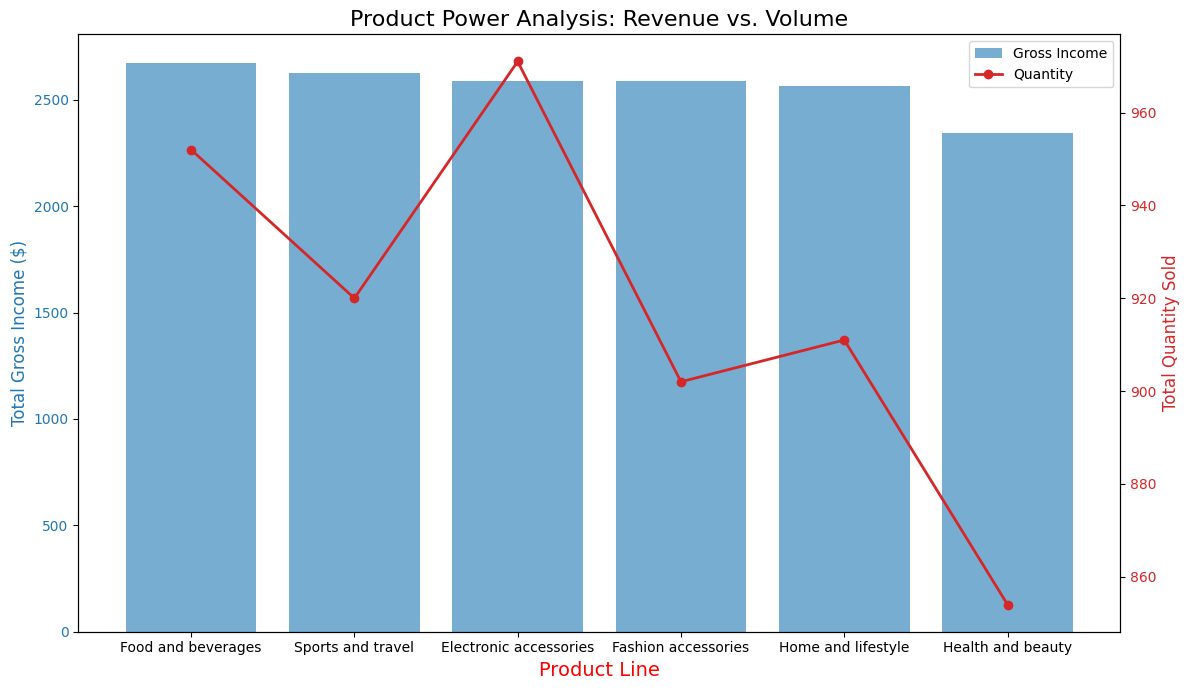

In [7]:
df = pd.read_csv('product_power_rankings.csv')

fig, ax1 = plt.subplots(figsize=(12, 7))

color_income = 'tab:blue'
ax1.set_xlabel('Product Line', fontsize=14, color='red')
ax1.set_ylabel('Total Gross Income ($)', color=color_income, fontsize=12)
bars = ax1.bar(df['Product line'], df['gross income'], color=color_income, alpha=0.6, label='Gross Income')
ax1.tick_params(axis='y', labelcolor=color_income)

ax2 = ax1.twinx()

color_qty = 'tab:red'
ax2.set_ylabel('Total Quantity Sold', color=color_qty, fontsize=12)
line = ax2.plot(df['Product line'], df['Quantity'], color=color_qty, marker='o', linewidth=2, label='Quantity')
ax2.tick_params(axis='y', labelcolor=color_qty)

plt.title('Product Power Analysis: Revenue vs. Volume', fontsize=16)
ax1.set_xticklabels(df['Product line'] )

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.savefig('product_power_analysis_chart.png', dpi=300)

### Y-AXIS REDEFINED (GROSS INCOME)

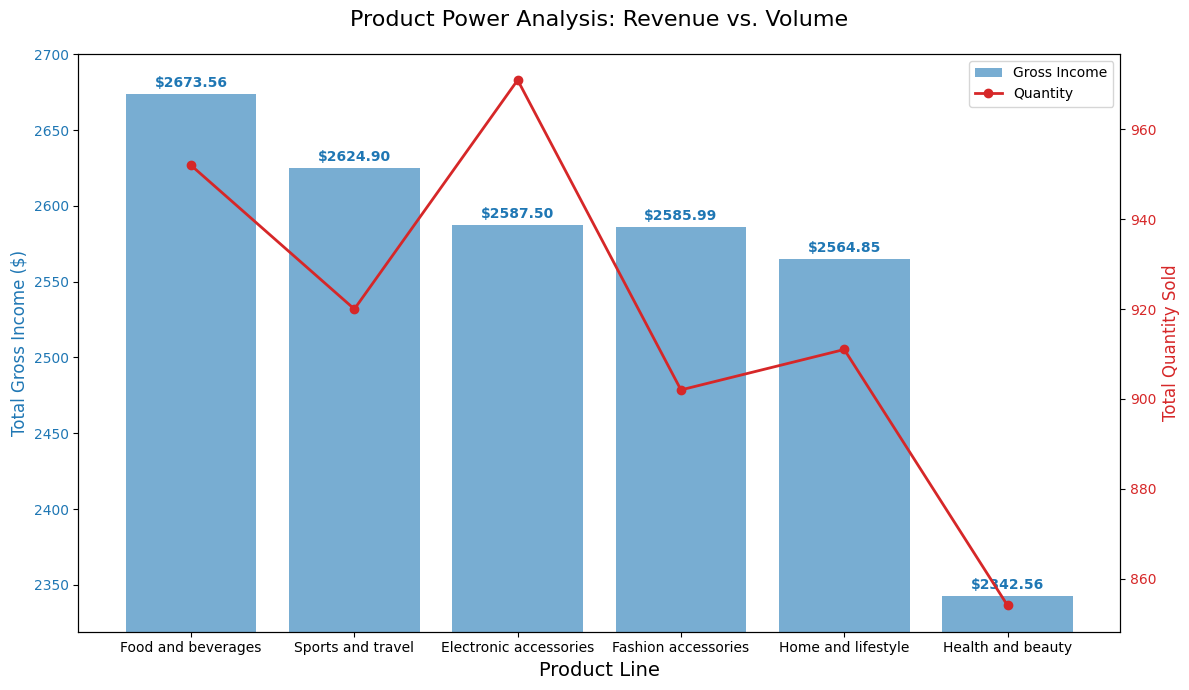

In [12]:
df = pd.read_csv('product_power_rankings.csv')

fig, ax1 = plt.subplots(figsize=(12, 7))

color_income = 'tab:blue'
ax1.set_xlabel('Product Line', fontsize=14, color='black')
ax1.set_ylabel('Total Gross Income ($)', color=color_income, fontsize=12)

bars = ax1.bar(df['Product line'], df['gross income'], color=color_income, alpha=0.6, label='Gross Income')
ax1.tick_params(axis='y', labelcolor=color_income)

ax1.bar_label(bars, padding=3, fmt='$%.2f', fontweight='bold', color=color_income)

min_val = df['gross income'].min()
max_val = df['gross income'].max()
ax1.set_ylim(min_val * 0.99, max_val * 1.01) 

ax2 = ax1.twinx()

color_qty = 'tab:red'
ax2.set_ylabel('Total Quantity Sold', color=color_qty, fontsize=12)
line = ax2.plot(df['Product line'], df['Quantity'], color=color_qty, marker='o', linewidth=2, label='Quantity')
ax2.tick_params(axis='y', labelcolor=color_qty)

plt.title('Product Power Analysis: Revenue vs. Volume', fontsize=16, pad=20)
ax1.set_xticks(range(len(df['Product line'])))
ax1.set_xticklabels(df['Product line'])

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()